<div style="background:linear-gradient(135deg,#042f2e 0%,#0f766e 55%,#2dd4bf 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#99f6e4;font-weight:700;text-transform:uppercase">Chapter 151 &middot; Tools &amp; Workflow &middot; Challenge Solutions</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Python for Data Analysis &middot; Solutions</div>
  <div style="font-size:15px;color:#ccfbf1;max-width:760px;line-height:1.6">Worked solutions to the five chapter challenges, one per area: pure-Python summary, a vectorized NumPy calculation, a pandas filter, a groupby-and-merge, and a plotted monthly trend.</div>
</div>

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi":110,"axes.grid":True,"grid.alpha":0.25,"font.size":11})
TL, TL2, AM, RD = "#0f766e", "#2dd4bf", "#d97706", "#dc2626"
BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "python-for-data-analysis--store-orders.xlsx"
def load(sheet="Orders"):
    try: return pd.read_excel("../../data/" + fn, sheet_name=sheet)
    except FileNotFoundError: return pd.read_excel(BASE + fn, sheet_name=sheet)

## Challenge 1 &middot; Summary statistics in pure Python
Given a list of order values, compute the count, mean, and max using only built-ins and a comprehension, no libraries.

In [2]:
values = [120.0, 80.0, 60.0, 200.0, 40.0, 95.0, 15.0, 250.0]
n = len(values); mean = sum(values) / n; biggest = max(values)
over_100 = [v for v in values if v > 100]
print(f"count {n} | mean {mean:.2f} | max {biggest:.2f} | over 100: {len(over_100)} orders")

count 8 | mean 107.50 | max 250.00 | over 100: 3 orders


## Challenge 2 &middot; A vectorized NumPy calculation
From the revenue array, report the share of revenue coming from orders over 100 dollars, and standardize the array to z-scores, all without a loop.

In [3]:
rev = load()["revenue"].to_numpy()
share = rev[rev > 100].sum() / rev.sum()
z = (rev - rev.mean()) / rev.std()
print(f"orders over 100 dollars make up {share:.1%} of revenue")
print(f"z-scores range from {z.min():.2f} to {z.max():.2f}, mean {z.mean():.2f}")

orders over 100 dollars make up 59.3% of revenue
z-scores range from -0.96 to 6.69, mean 0.00


## Challenge 3 &middot; Filter with pandas
Load the orders, keep web orders placed in the fourth quarter (October to December), and report how many there are and their total revenue.

In [4]:
orders = load(); orders["order_date"] = pd.to_datetime(orders.order_date)
q4_web = orders[(orders.channel == "web") & (orders.order_date.dt.quarter == 4)]
print("Q4 web orders:", len(q4_web), "| revenue:", round(q4_web.revenue.sum(), 2))

Q4 web orders: 357 | revenue: 27256.95


## Challenge 4 &middot; groupby with a merge
Join the products table, then report revenue and profit by category, sorted by profit.

In [5]:
orders = load(); products = load("Products")
m = orders.merge(products, on="product_id", how="left")
m["profit"] = m.revenue - m.quantity * m.unit_cost
summary = m.groupby("category").agg(revenue=("revenue", "sum"), profit=("profit", "sum")).sort_values("profit", ascending=False).round(2)
print(summary.to_string())

              revenue   profit
category                      
Equipment    115918.4  56861.4
Beans         74806.2  33850.2
Accessories   37251.5  23498.0
Other          8132.5   8132.5


## Challenge 5 &middot; Plot the monthly trend
Plot 2024 revenue by month as a line and mark the peak month.

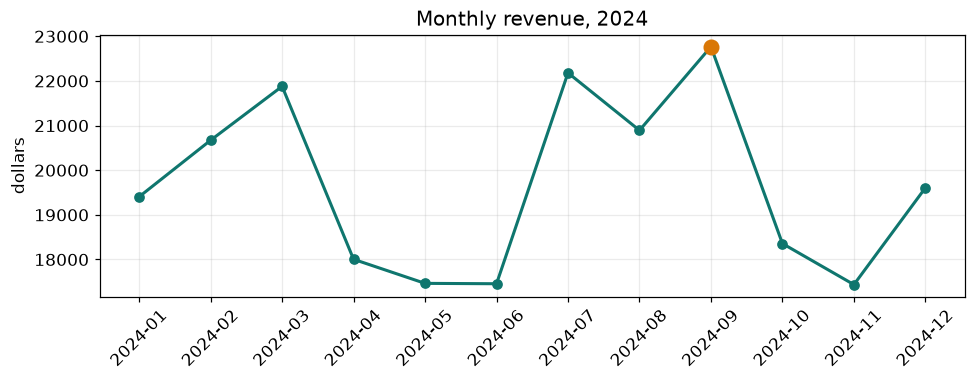

peak month: 2024-09 at 22765.9


In [6]:
orders = load(); orders["order_date"] = pd.to_datetime(orders.order_date)
monthly = orders.groupby(orders.order_date.dt.to_period("M")).revenue.sum(); monthly.index = monthly.index.astype(str)
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(monthly.index, monthly.values, marker="o", color=TL, lw=2)
ax.scatter([monthly.idxmax()], [monthly.max()], color=AM, s=90, zorder=5)
ax.set_title("Monthly revenue, 2024"); ax.set_ylabel("dollars"); ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()
print("peak month:", monthly.idxmax(), "at", round(monthly.max(), 2))